<a href="https://colab.research.google.com/github/Striver29/CrossEnrich/blob/main/CrossEnrich_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase 1: Hardcoded data collection**

In [5]:
!pip install gprofiler-official matplotlib seaborn --quiet
print("done")

done


In [6]:
from gprofiler import GProfiler
import pandas as pd

In [7]:
gene_list = ["TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
"SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
"CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2"]

print(len(gene_list))
print(gene_list)

23
['TP53', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'GADD45A', 'GADD45B', 'SESN1', 'SESN2', 'RRM2B', 'DRAM1', 'FAS', 'TNFRSF10B', 'APAF1', 'CASP3', 'CASP9', 'CYCS', 'PTEN', 'ATM', 'ATR', 'BRCA1', 'BRCA2']


In [8]:
gp = GProfiler()
results = gp.profile(gene_list, organism="hsapiens", no_evidences=False) #no_evidences=False is set to show intersections
results = pd.DataFrame(results)
print(results.shape)

(608, 16)


In [9]:
results.head()

,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,p53 signaling pathway,8484,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,5.941134e-39,[KEGG:00000],0.909091,query_1,22,0.270270,True,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,8.715110e-36,[WP:000000],0.826087,query_1,23,0.275362,True,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
2,miRNA regulation of DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.994203e-35,[WP:000000],0.826087,query_1,23,0.260274,True,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
3,Platinum drug resistance,8484,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.175199e-20,[KEGG:00000],0.590909,query_1,22,0.180556,True,KEGG,72,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
4,miRNA regulation of p53 pathway in prostate ca...,8752,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.706305e-20,[WP:000000],0.478261,query_1,23,0.354839,True,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."


In [10]:
print(results["source"].unique())

['KEGG' 'WP' 'REAC' 'GO:BP' 'HP' 'GO:CC' 'MIRNA' 'CORUM' 'GO:MF' 'TF'
 'HPA']


**Note: We treat GO as three separate databases:**

GO:BP (Biological Processes)

GO:CC (Cellular Component)

GO:MF (Molecular Function)

For interpretability, GO is kept split into GO:BP, GO:CC, and GO:MF. In this notebook we also keep WP, giving six sources in the exploratory comparison: GO:BP, GO:CC, GO:MF, KEGG, REAC, and WP.

#**Phase 2: Source filtering**




In [11]:
df_gobp = results[results["source"] == "GO:BP"]
df_gocc = results[results["source"] == "GO:CC"]
df_gomf = results[results["source"] == "GO:MF"]
df_kegg = results[results["source"] == "KEGG"]
df_reac = results[results["source"] == "REAC"]
df_wp = results[results["source"] == "WP"]

The code below keeps only terms marked significant by g:Profiler after multiple-testing correction.

In [12]:
df_gobp = df_gobp[df_gobp["significant"] == True]
df_gocc = df_gocc[df_gocc["significant"] == True]
df_gomf = df_gomf[df_gomf["significant"] == True]
df_kegg = df_kegg[df_kegg["significant"] == True]
df_reac = df_reac[df_reac["significant"] == True]
df_wp = df_wp[df_wp["significant"] == True]

In [13]:
print("GO:BP ",df_gobp.shape)
print("GO:CC ",df_gocc.shape)
print("GO:MF ", df_gomf.shape)
print("KEGG ", df_kegg.shape)
print("REAC ", df_reac.shape)
print("WP ", df_wp.shape)

GO:BP  (236, 16)
GO:CC  (12, 16)
GO:MF  (13, 16)
KEGG  (54, 16)
REAC  (76, 16)
WP  (68, 16)


#**Phase 3: Consistency and Metrics**




**Term Jaccard**



In [14]:
#mock example of two databases and direct name matching.

df_kegg_set = set(df_kegg["name"])
df_reac_set = set(df_reac["name"])

union = df_kegg_set.union(df_reac_set)
intersection = df_kegg_set.intersection(df_reac_set)

jaccard = len(intersection)/len(union)
print(jaccard)

0.007751937984496124


In [15]:
print(intersection)

#only one direct match

{'Apoptosis'}


In [16]:
#function for cross-database name direct matching.

def term_jaccard(db1, db2):
  db1_set = set(db1["name"])
  db2_set = set(db2["name"])

  union = db1_set.union(db2_set)
  intersection = db1_set.intersection(db2_set)

  if len(union) == 0:
    jaccard = 0
  else:
    jaccard = len(intersection)/len(union)

  return jaccard

In [17]:
databases = [
    ("GO:BP", df_gobp),
    ("GO:CC", df_gocc),
    ("GO:MF", df_gomf),
    ("KEGG", df_kegg),
    ("REAC", df_reac),
    ("WP", df_wp)
]

db_names = [name for name, df in databases]
matrix_df = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range(len(databases)):
    name_i, df_i = databases[i]
    for j in range(i+1, len(databases)):
        name_j, df_j = databases[j]
        score = term_jaccard(df_i, df_j)
        matrix_df.at[name_i, name_j] = score
        matrix_df.at[name_j, name_i] = score

print(matrix_df)

        GO:BP  GO:CC  GO:MF      KEGG      REAC        WP
GO:BP     NaN    0.0    0.0  0.000000  0.000000  0.003300
GO:CC  0.0000    NaN    0.0  0.000000  0.000000  0.000000
GO:MF  0.0000    0.0    NaN  0.000000  0.000000  0.000000
KEGG   0.0000    0.0    0.0       NaN  0.007752  0.051724
REAC   0.0000    0.0    0.0  0.007752       NaN  0.006993
WP     0.0033    0.0    0.0  0.051724  0.006993       NaN


**Results indicate that direct name comparison yeild nearly zero consistency**

# **Gene-level Jaccard**

In [18]:
#Checks for overlap based on terms and returns the highest overlap among two terms.
#the overlaps are then averaged for a final database-database gene_level score
def gene_jaccard_term(genes1, genes2):
    set1 = set(genes1)
    set2 = set(genes2)
    union = set1.union(set2)
    if len(union) == 0:
        return 0
    return len(set1.intersection(set2)) / len(union)

def gene_jaccard(db1, db2):

  term_scores = list()
  for idx1, row1 in db1.iterrows():
    best_score = 0

    for idx2, row2 in db2.iterrows():
        score = gene_jaccard_term(row1["intersections"], row2["intersections"])

        if score >= 0.5 and score > best_score:
            best_score = score

    if best_score != 0:
      term_scores.append(best_score)


  if len(term_scores) == 0:
    return 0
  else:
    return sum(term_scores)/len(term_scores)


In [19]:
print(gene_jaccard(df_kegg, df_reac)) #About 69% agreement with gene_level agreement

0.6960463011933601


In [20]:
#building the level agreement over the 5 databases

matrix_df_gene_level = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range (len(databases)):
  name_i, db_i = databases[i]
  for j in range(i+1, len(databases)):
    name_j, db_j = databases[j]
    score = gene_jaccard(db_i, db_j)
    matrix_df_gene_level.at[name_i, name_j] = score
    #matrix_df_gene_level.at[name_j, name_i] = score

print(matrix_df_gene_level)

       GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP    NaN  0.638011  0.594935  0.634765  0.646506  0.657019
GO:CC    NaN       NaN  0.560965  0.697826  0.683779  0.676864
GO:MF    NaN       NaN       NaN  0.574838  0.617851  0.671672
KEGG     NaN       NaN       NaN       NaN  0.696046  0.815816
REAC     NaN       NaN       NaN       NaN       NaN  0.781863
WP       NaN       NaN       NaN       NaN       NaN       NaN


# **Spearman Correlation**

In [21]:
from scipy.stats import spearmanr
def gene_jaccard_term(genes1, genes2):
    set1 = set(genes1)
    set2 = set(genes2)
    union = set1.union(set2)
    if len(union) == 0:
        return 0
    return len(set1.intersection(set2)) / len(union)

def spearman_correlation(db1, db2):

    db1_pvals = []
    db2_pvals = []

    for idx1, row1 in db1.iterrows():
        best_score = 0
        best_pval = None

        for idx2, row2 in db2.iterrows():
            score = gene_jaccard_term(row1["intersections"], row2["intersections"])
            if score >= 0.5 and score > best_score:
                best_score = score
                best_pval = row2["p_value"]

        if best_pval is not None:
            db1_pvals.append(row1["p_value"])
            db2_pvals.append(best_pval)

    spearman = spearmanr(db1_pvals, db2_pvals)
    return spearman.correlation


In [22]:
print(spearman_correlation(df_kegg, df_reac))

0.37927918929484117


In [23]:
matrix_df_spearman = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range (len(databases)):
  name_i, db_i = databases[i]
  for j in range (i+1, len(databases)):
    name_j, db_j = databases[j]

    score = spearman_correlation(db_i, db_j)
    matrix_df_spearman.at[name_i, name_j] = score
    matrix_df_spearman.at[name_j, name_i] = score

print(matrix_df_spearman)

          GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP       NaN  0.002083  0.058833  0.435762  0.330438  0.457200
GO:CC  0.002083       NaN  0.925820 -0.065290 -0.317887 -0.202784
GO:MF  0.058833  0.925820       NaN  0.738769  0.201688 -0.139818
KEGG   0.435762 -0.065290  0.738769       NaN  0.379279  0.602388
REAC   0.330438 -0.317887  0.201688  0.379279       NaN  0.416784
WP     0.457200 -0.202784 -0.139818  0.602388  0.416784       NaN


# **Phase 4: Using the reusable CrossEnrich package**

The cells below show how to take the real `results` DataFrame returned by g:Profiler and pass it through the reusable package modules in `src/crossenrich/`. Start with a small top-ranked subset so the similarity and cluster outputs stay readable.

In [24]:
import sys
sys.path.append("/Users/abdulazizalshujaa/Desktop/CrossEnrich/src")

from crossenrich.standardization import standardize_results_frame
from crossenrich.semantic import (
    build_semantic_similarity_matrix,
    cluster_terms,
    build_cluster_consistency_matrix,
)
from crossenrich.validation import validate_score_matrix, summarize_cluster_quality

import matplotlib.pyplot as plt
import seaborn as sns


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33700.75it/s]
BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
standardized = standardize_results_frame(results)

small_results = (
    standardized.sort_values("p_value")
    .groupby("canonical_source", group_keys=False)
    .head(80)
    .reset_index(drop=True)
)

print("Standardized shape:", standardized.shape)
print("Small demo shape:", small_results.shape)
display(small_results[["canonical_source", "name", "p_value", "rank_within_source"]])


Standardized shape: (459, 23)
Small demo shape: (303, 23)


,canonical_source,name,p_value,rank_within_source
0,KEGG,p53 signaling pathway,5.941134e-39,1
1,WP,DNA damage response,8.715110e-36,1
2,WP,miRNA regulation of DNA damage response,2.994203e-35,2
3,KEGG,Platinum drug resistance,1.175199e-20,2
4,WP,miRNA regulation of p53 pathway in prostate ca...,2.706305e-20,3
...,...,...,...,...
298,REAC,Regulation by c-FLIP,4.989271e-02,58
299,REAC,CASP8 activity is inhibited,4.989271e-02,58
300,REAC,Caspase activation via Dependence Receptors in...,4.989271e-02,58
301,REAC,Dimerization of procaspase-8,4.989271e-02,58


Term-term similarity matrix:


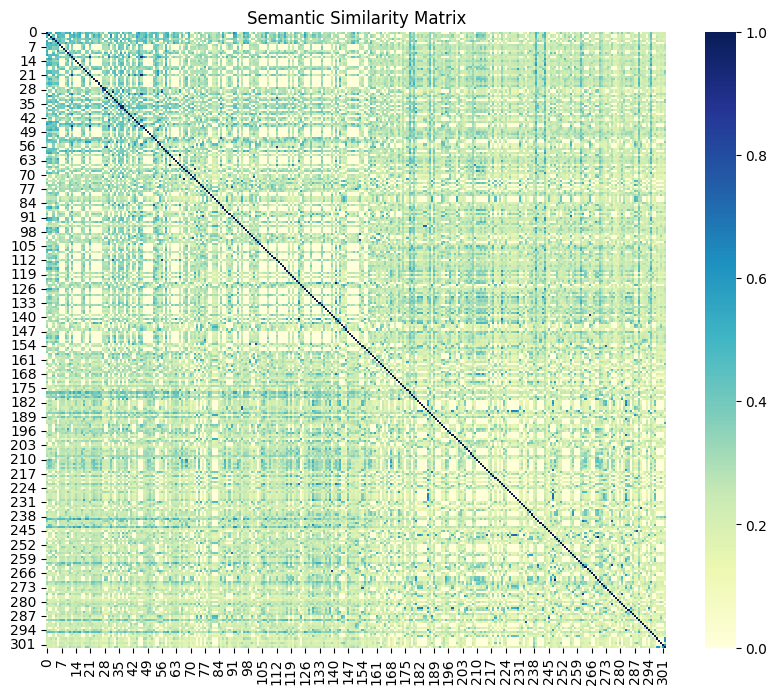

,0,1,2,3,4,5,6,7,8,9,...,293,294,295,296,297,298,299,300,301,302
0,1.00,0.53,0.53,0.00,0.55,0.52,0.52,0.40,0.39,0.53,...,0.21,0.22,0.42,0.24,0.20,0.23,0.22,0.21,0.21,0.21
1,0.53,1.00,0.00,0.44,0.00,0.48,0.44,0.46,0.46,0.00,...,0.00,0.27,0.44,0.00,0.00,0.22,0.22,0.21,0.21,0.21
2,0.53,0.00,1.00,0.43,0.00,0.55,0.45,0.45,0.45,0.00,...,0.00,0.25,0.44,0.00,0.00,0.28,0.21,0.22,0.22,0.20
3,0.00,0.44,0.43,1.00,0.42,0.39,0.44,0.36,0.36,0.29,...,0.20,0.22,0.41,0.21,0.20,0.20,0.19,0.21,0.18,0.18
4,0.55,0.00,0.00,0.42,1.00,0.44,0.48,0.39,0.38,0.00,...,0.00,0.21,0.33,0.00,0.00,0.28,0.20,0.25,0.23,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.23,0.22,0.28,0.20,0.28,0.00,0.20,0.25,0.24,0.26,...,0.17,0.00,0.21,0.26,0.16,1.00,0.00,0.00,0.00,0.60
299,0.22,0.22,0.21,0.19,0.20,0.00,0.18,0.22,0.21,0.24,...,0.14,0.00,0.18,0.23,0.17,0.00,1.00,0.00,0.00,0.62
300,0.21,0.21,0.22,0.21,0.25,0.00,0.26,0.24,0.23,0.16,...,0.15,0.00,0.23,0.15,0.15,0.00,0.00,1.00,0.00,0.21
301,0.21,0.21,0.22,0.18,0.23,0.00,0.21,0.23,0.23,0.24,...,0.15,0.00,0.21,0.23,0.15,0.00,0.00,0.00,1.00,0.59


Clustered term table:


,canonical_source,name,standardized_name,cluster_id,cluster_label,semantic_similarity_max
113,GO:BP,positive regulation of response to stimulus,positive regulation of response to stimulus,0,positive regulation of response to stimulus,0.489600
192,REAC,TP53 Regulates Transcription of Death Receptor...,tp53 regulates transcription of death receptor...,0,positive regulation of response to stimulus,0.530283
302,GO:MF,death receptor activity,death receptor activity,1,casp8 activity is inhibited,0.623785
299,REAC,CASP8 activity is inhibited,casp8 activity is inhibited,1,casp8 activity is inhibited,0.623785
301,REAC,Dimerization of procaspase-8,dimerization of procaspase 8,1,casp8 activity is inhibited,0.593907
...,...,...,...,...,...,...
251,WP,TNF alpha signaling,tnf alpha signaling,34,apoptosis,0.501228
290,KEGG,Non-alcoholic fatty liver disease,non alcoholic fatty liver disease,35,nonalcoholic fatty liver disease,0.798300
266,REAC,Release of apoptotic factors from the mitochon...,release of apoptotic factors from the mitochon...,35,nonalcoholic fatty liver disease,0.412717
234,WP,Nonalcoholic fatty liver disease,nonalcoholic fatty liver disease,35,nonalcoholic fatty liver disease,0.798300


Database-level cluster consistency matrix:


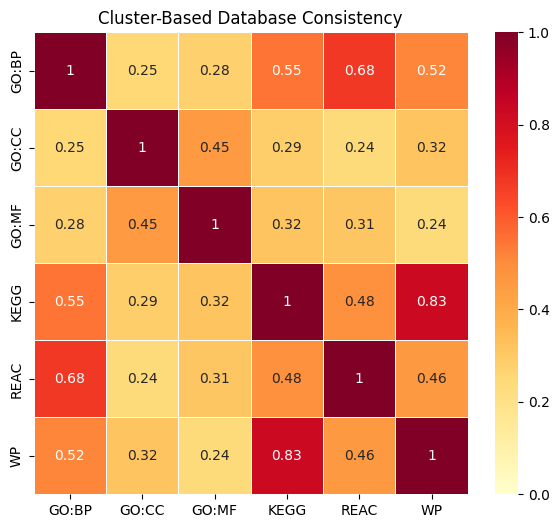

,GO:BP,GO:CC,GO:MF,KEGG,REAC,WP
GO:BP,1.00,0.25,0.28,0.55,0.68,0.52
GO:CC,0.25,1.00,0.45,0.29,0.24,0.32
GO:MF,0.28,0.45,1.00,0.32,0.31,0.24
KEGG,0.55,0.29,0.32,1.00,0.48,0.83
REAC,0.68,0.24,0.31,0.48,1.00,0.46
WP,0.52,0.32,0.24,0.83,0.46,1.00


Validation summary:
{'is_valid': True, 'issues': [], 'shape': (6, 6)}
Cluster summary:
{'term_count': 303, 'cluster_count': 37, 'singleton_cluster_count': 7, 'multi_source_cluster_count': 30, 'mean_cluster_size': 8.18918918918919}


In [26]:
small_similarity = build_semantic_similarity_matrix(small_results)
small_clustered = cluster_terms(small_results, similarity_threshold=0.25)
small_cluster_matrix = build_cluster_consistency_matrix(small_clustered)

print("Term-term similarity matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(small_similarity, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Matrix")
plt.show()
display(small_similarity.round(2))

print("Clustered term table:")
display(
    small_clustered[[
        "canonical_source",
        "name",
        "standardized_name",
        "cluster_id",
        "cluster_label",
        "semantic_similarity_max",
    ]].sort_values(["cluster_id", "canonical_source"])
)

print("Database-level cluster consistency matrix:")
plt.figure(figsize=(7, 6))
sns.heatmap(
    small_cluster_matrix,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Cluster-Based Database Consistency")
plt.show()
display(small_cluster_matrix.round(2))

validation = validate_score_matrix(
    small_cluster_matrix,
    expected_min=0.0,
    expected_max=1.0,
    diagonal_mode="one",
)
summary = summarize_cluster_quality(small_clustered)

print("Validation summary:")
print(validation)
print("Cluster summary:")
print(summary)
